# MLHW 5-2

## Task 0 – Generate Synthetic Data

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, balanced_accuracy_score,
                             classification_report)
from sklearn.inspection import permutation_importance

X, y = make_moons(n_samples=5000, noise=0.2, random_state=0)

rng = np.random.default_rng(42)
X_noise = rng.normal(size=(X.shape[0], 8))

X = np.hstack([X, X_noise])
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (5000, 10), y shape: (5000,)


## Task 1 – Scatter Plot of X₁ vs X₂

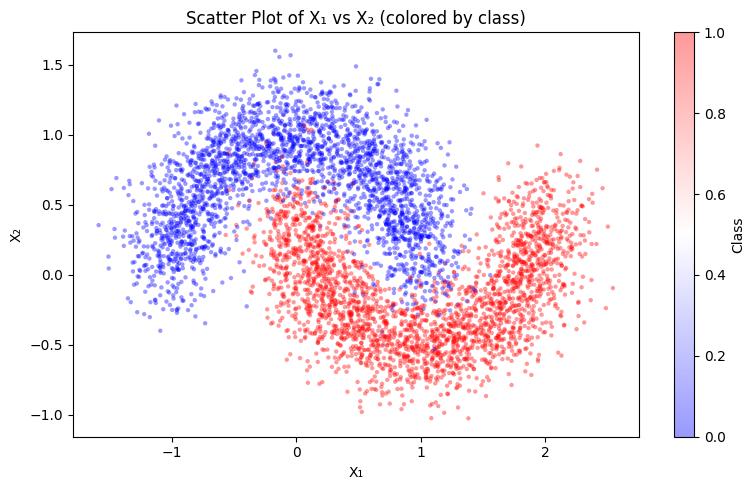

In [11]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.4, s=10, edgecolors='none')
plt.colorbar(scatter, label='Class')
plt.xlabel('X₁')
plt.ylabel('X₂')
plt.title('Scatter Plot of X₁ vs X₂ (colored by class)')
plt.tight_layout()
plt.show()

## Task 2 – Standardize and Split

In [12]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")

Train: (3000, 10), Val: (1000, 10), Test: (1000, 10)


## Task 3 – GridSearchCV for SVC

In [13]:
param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.1, 1]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'degree': [2, 3, 4],
        'coef0': [0, 1],
        'gamma': ['scale', 0.1]
    }
]

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train_s, y_train)
print("GridSearch complete.")

GridSearch complete.


## Task 4 – Cross-Validation Results Summary

In [14]:
results = pd.DataFrame(grid_search.cv_results_)
cols = [c for c in results.columns if c.startswith('param_')] + [
    'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']
results_table = results[cols].sort_values('rank_test_score')
results_table.head(20)

,param_C,param_gamma,param_kernel,param_coef0,param_degree,mean_test_score,std_test_score,mean_train_score,rank_test_score
61,100.0,0.1,poly,1.0,3.0,0.925333,0.008844,0.987083,1
60,100.0,scale,poly,1.0,3.0,0.925000,0.008628,0.987000,2
55,100.0,0.1,poly,0.0,3.0,0.920333,0.011898,0.967750,3
54,100.0,scale,poly,0.0,3.0,0.920000,0.012472,0.967833,4
49,10.0,0.1,poly,1.0,3.0,0.919667,0.011126,0.966250,5
48,10.0,scale,poly,1.0,3.0,0.919333,0.011624,0.966250,6
42,10.0,scale,poly,0.0,3.0,0.907333,0.013888,0.945917,7
43,10.0,0.1,poly,0.0,3.0,0.906667,0.013663,0.945667,8
39,1.0,0.1,poly,1.0,4.0,0.902000,0.012311,0.966583,9
38,1.0,scale,poly,1.0,4.0,0.901667,0.011499,0.966500,10


**Interpretation:** Poly kernel (degree 3) consistently outperforms RBF, achieving ~92.5% vs ~90% CV accuracy. Higher C (100) and coef0=1 improve poly performance. RBF with C=100 shows a larger train–test gap (>10%) than poly (~6%), indicating RBF overfits more with 8 noise features present.

## Task 5 – Best Model from GridSearch

In [15]:
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))
print("Best estimator:", grid_search.best_estimator_)

Best parameters: {'C': 100, 'coef0': 1, 'degree': 3, 'gamma': 0.1, 'kernel': 'poly'}
Best CV accuracy: 0.9253
Best estimator: SVC(C=100, coef0=1, gamma=0.1, kernel='poly')


**Interpretation:** Best model: **SVC(C=100, poly, degree=3, gamma=0.1, coef0=1)** with CV accuracy 92.53%. The cubic poly kernel captures the nonlinear moon boundary while being more robust to noise dimensions than RBF, and the moderate train–test gap confirms controlled overfitting.

## Task 6 – Test Set Evaluation

Test accuracy: 0.94
Balanced accuracy: 0.94

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       500
           1       0.93      0.95      0.94       500

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



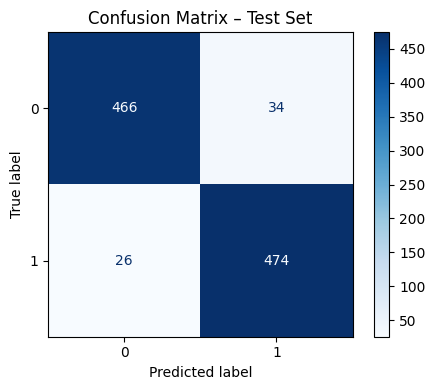

In [16]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_s)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix – Test Set')
plt.tight_layout()
plt.show()

**Interpretation:** Test accuracy = 94%, balanced accuracy = 94%. The confusion matrix (466/34 vs 26/474) shows roughly symmetric errors across classes. The 60 misclassifications concentrate near the overlapping moon boundary where noise blurs class separation.

## Task 7 – Decision Boundary Visualization

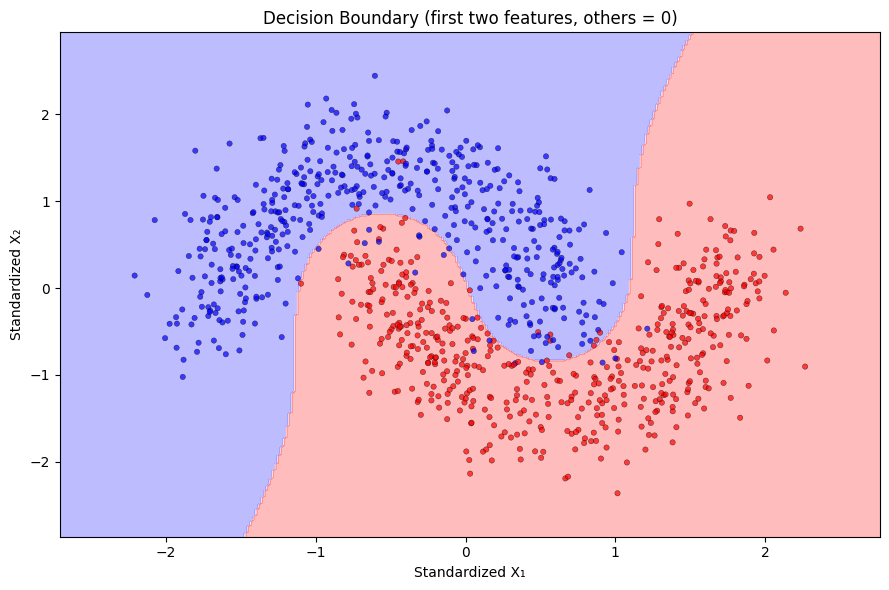

In [17]:
x_min, x_max = X_test_s[:, 0].min() - 0.5, X_test_s[:, 0].max() + 0.5
y_min, y_max = X_test_s[:, 1].min() - 0.5, X_test_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

grid = np.zeros((xx.ravel().shape[0], X_test_s.shape[1]))
grid[:, 0] = xx.ravel()
grid[:, 1] = yy.ravel()

Z = best_model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X_test_s[:, 0], X_test_s[:, 1], c=y_test, cmap='bwr',
            edgecolors='k', s=15, linewidths=0.3, alpha=0.7)
plt.xlabel('Standardized X₁')
plt.ylabel('Standardized X₂')
plt.title('Decision Boundary (first two features, others = 0)')
plt.tight_layout()
plt.show()

## Task 8 – Permutation Feature Importance

Feature  Mean Importance      Std
     X2         0.294500 0.012969
     X1         0.238400 0.010128
     X8         0.004833 0.002899
     X6         0.002533 0.004303
     X4         0.002433 0.004129
     X3         0.001600 0.003818
     X7        -0.000800 0.004003
     X5        -0.002300 0.003532
     X9        -0.005200 0.003961
    X10        -0.008100 0.002856


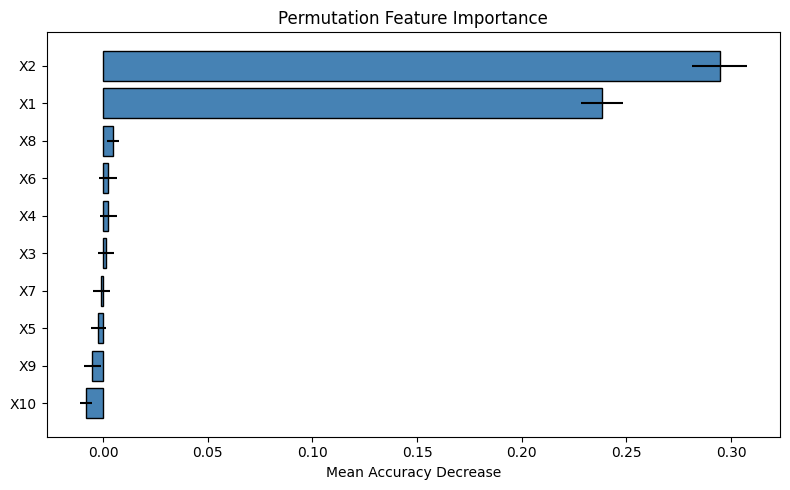

In [18]:
feature_names = [f'X{i+1}' for i in range(X_test_s.shape[1])]

perm_imp = permutation_importance(
    best_model, X_test_s, y_test,
    n_repeats=30, random_state=42, scoring='accuracy', n_jobs=-1)

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Mean Importance', ascending=False)
print(imp_df.to_string(index=False))

plt.figure(figsize=(8, 5))
order = imp_df['Feature'].values[::-1]
means = imp_df.set_index('Feature').loc[order, 'Mean Importance']
stds = imp_df.set_index('Feature').loc[order, 'Std']
plt.barh(order, means, xerr=stds, color='steelblue', edgecolor='k')
plt.xlabel('Mean Accuracy Decrease')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

**Interpretation:** X₁ and X₂ dominate with importance ~0.24 and ~0.29, confirming they are the only informative features. X₃–X₁₀ (noise) all have importance ≈ 0, showing the SVM successfully ignores irrelevant dimensions. This aligns with the data-generating process where only the first two features encode the moon structure.